In [1]:
import cv2
import os 
from collections import defaultdict
from PIL import Image
import math
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dire = "../data"
area_whole = defaultdict()
for filename in os.listdir(dire):
    # print(dire)
    # print(filename)
    if filename != ".DS_Store":
        img = Image.open(f"{dire}/{filename}")
        a,b = img.size
        area= a*b
        if area not in area_whole.keys():
            area_whole[area] = 1
        else:
            area_whole[area] +=1



In [28]:
print(ab)

defaultdict(None, {(26, 69): 1, (63, 58): 14, (74, 98): 5, (41, 38): 18, (27, 31): 14, (37, 37): 18, (83, 43): 5, (39, 51): 18, (211, 137): 1, (159, 100): 1, (61, 77): 5, (74, 61): 13, (185, 58): 2, (57, 65): 8, (58, 43): 10, (78, 52): 5, (52, 48): 9, (31, 48): 6, (63, 57): 9, (84, 71): 5, (36, 38): 8, (40, 25): 6, (32, 22): 4, (83, 104): 2, (131, 94): 2, (66, 45): 10, (29, 29): 10, (52, 57): 11, (93, 53): 2, (43, 49): 9, (44, 49): 25, (68, 33): 10, (168, 104): 1, (68, 48): 4, (98, 59): 1, (33, 50): 4, (47, 14): 1, (64, 35): 6, (60, 68): 5, (118, 120): 1, (31, 25): 7, (43, 47): 10, (52, 47): 8, (82, 82): 8, (75, 69): 3, (88, 44): 5, (39, 46): 18, (27, 23): 8, (116, 103): 5, (68, 65): 7, (31, 20): 1, (53, 53): 14, (39, 65): 3, (31, 35): 13, (116, 47): 2, (42, 44): 20, (49, 47): 10, (127, 92): 1, (45, 39): 10, (35, 49): 2, (67, 55): 5, (130, 75): 1, (57, 58): 9, (52, 51): 12, (105, 34): 3, (32, 30): 14, (55, 100): 1, (78, 41): 5, (66, 56): 9, (44, 69): 2, (51, 78): 1, (93, 55): 3, (87, 7

In [4]:


def plot_hist_of_area(area_counts_dict, N_BINS=60, use_log_scale=True):
    """
    Generates a histogram for image area counts, where dictionary keys are the areas 
    (integers) and values are the counts.
    
    Args:
        area_counts_dict (dict): Dictionary with area (int) as key and count (int) as value.
        N_BINS (int): Number of bins for the histogram.
        use_log_scale (bool): If True, plots the x-axis (Area) on a logarithmic scale.
    """
    print(f"Plotting histogram of image area with {N_BINS} bins...")

    # 1. Transform the aggregated data (counts) into a list of individual numerical areas.
    # The keys are already the numerical values (areas).
    numerical_areas = []
    
    for area, count in area_counts_dict.items():
        # Extend the list by the numerical area 'count' times
        numerical_areas.extend([area] * count)
        
    if not numerical_areas:
        print("Error: The area dictionary is empty or contains no data.")
        return

    # Convert to numpy array for efficiency
    numerical_areas = np.array(numerical_areas)


    # 2. Create the Histogram
    plt.figure(figsize=(12, 7))

    # Determine scale for binning
    if use_log_scale:
        # Define logarithmic bins
        min_area = np.min(numerical_areas)
        max_area = np.max(numerical_areas)
        
        # Ensure minimum is not zero/negative for log scale
        if min_area <= 0:
            min_area = 1 
            
        log_bins = np.logspace(np.log10(min_area), np.log10(max_area), N_BINS + 1)
        
        # Plot with log scale
        plt.hist(numerical_areas, bins=log_bins, edgecolor='black', alpha=0.7, color='teal')
        plt.xscale('log') # Set the x-axis to logarithmic scale
        
        x_label = "Image Area (Pixels) [Log Scale]"
        
    else:
        # Standard linear scale plot
        plt.hist(numerical_areas, bins=N_BINS, edgecolor='black', alpha=0.7, color='teal')
        x_label = "Image Area (Pixels)"


    # 3. Dynamic X-axis Labeling (Revert to standard numerical ticks)

    # Standard numerical ticks are typically better for continuous data like area
    # We will skip the complex string-labeling logic and rely on matplotlib's auto-formatter.
    
    # If using log scale, improve tick visibility by labeling powers of 10
    if use_log_scale:
        ax = plt.gca()
        # Find ticks that are powers of 10
        area_range = np.log10(np.max(numerical_areas)) - np.log10(np.min(numerical_areas))
        tick_interval = np.ceil(area_range / 5) # Label every 10^n
        
        # Manually set major ticks (powers of 10)
        start_power = int(np.floor(np.log10(np.min(numerical_areas))))
        end_power = int(np.ceil(np.log10(np.max(numerical_areas))))
        
        log_ticks = [10**i for i in range(start_power, end_power + 1)]
        log_labels = [f'{t:,}' for t in log_ticks]
        
        # Set ticks only if there are a reasonable number of them
        if len(log_ticks) <= 10:
             ax.set_xticks(log_ticks)
             ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=10)
        else:
             # Too many labels, just use the auto-generated ones
             plt.xticks(rotation=45, ha='right', fontsize=10)

    else:
        # For linear scale, just rotate for visibility
        plt.xticks(rotation=45, ha='right', fontsize=10)


    # 4. Add remaining formatting
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Frequency (Count of Images)", fontsize=12)
    plt.title(f"Histogram of Image Area Distribution (Bins: {N_BINS})", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # 5. Save the plot
    output_filename = "image_area_histogram_log.png" if use_log_scale else "image_area_histogram_linear.png"
    plt.savefig(output_filename)
    print(f"Histogram saved as '{output_filename}'")

# --- Example of how to call the function ---
# Assuming 'ab' is your dictionary of image areas:
# 

Plotting histogram of image area with 60 bins...
Histogram saved as 'image_area_histogram_log.png'


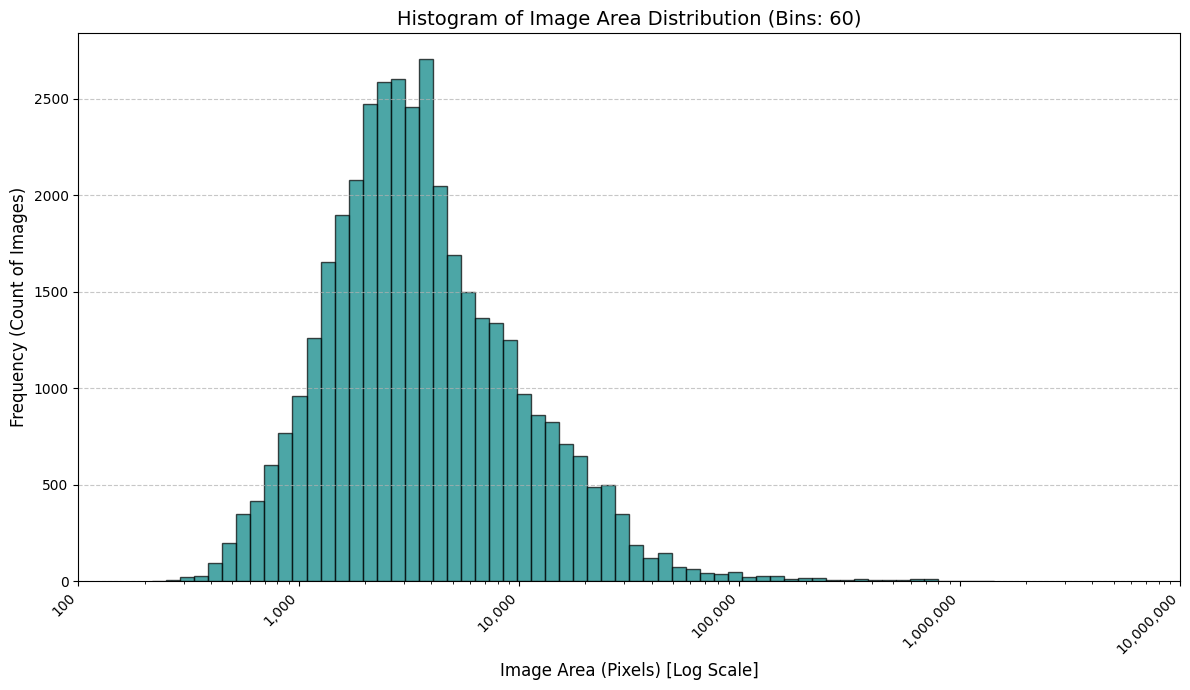

In [5]:
plot_hist_of_area(area_whole)

now for the filtered data

In [6]:

def from_img_path(img_path):
    # --- CONFIGURATION ---
    # 1. SET THE PATH TO YOUR LIST OF IMAGE PATHS (.txt file from the previous script)
    # Option A: Kept Data
    IMAGE_PATHS_FILE = img_path
    # Option B: Filtered Out Data (Uncomment this and comment A to switch)
    # IMAGE_PATHS_FILE = "../mahala_median/filtered_out_image_paths.txt"
    # ---------------------

    aspect_ratio_counts_filtered = defaultdict(int)

    # 1. Read all image paths from the text file
    try:
        with open(IMAGE_PATHS_FILE, 'r') as f:
            # Read lines, strip whitespace (including newline), and filter out empty lines
            image_paths = [line.strip() for line in f if line.strip()]
    except FileNotFoundError:
        print(f"❌ Error: The file {IMAGE_PATHS_FILE} was not found. Please check the path.")
        image_paths = []

    print(f"Processing {len(image_paths)} image paths from {IMAGE_PATHS_FILE}...")


    # 2. Iterate over the list of paths
    for image_path in image_paths:
        # Use the full path read from the file directly with Image.open()
        try:
            # Check if the path exists before attempting to open the image
            if not os.path.exists(image_path):
                print(f"Skipping file: Path does not exist: {image_path}")
                continue

            img = Image.open(image_path)
            width, height = img.size # size is returned as (width, height)

            area= width*height
            if area not in aspect_ratio_counts_filtered.keys():
                aspect_ratio_counts_filtered[area] = 1
            else:
                aspect_ratio_counts_filtered[area] +=1
                
        except Exception as e:
            print(f"Skipping file {image_path} due to error: {e}")

    print("\nAspect Ratio Counts (Ready for Histogram Plotting):")
    return(dict(aspect_ratio_counts_filtered))

In [7]:
area_kept = from_img_path("../mahala_median/kept_image_paths.txt")
area_deleted = from_img_path("../mahala_median/filtered_out_image_paths.txt")

Processing 29047 image paths from ../mahala_median/kept_image_paths.txt...

Aspect Ratio Counts (Ready for Histogram Plotting):
Processing 9525 image paths from ../mahala_median/filtered_out_image_paths.txt...

Aspect Ratio Counts (Ready for Histogram Plotting):


Plotting histogram of image area with 60 bins...
Histogram saved as 'image_area_histogram_log.png'


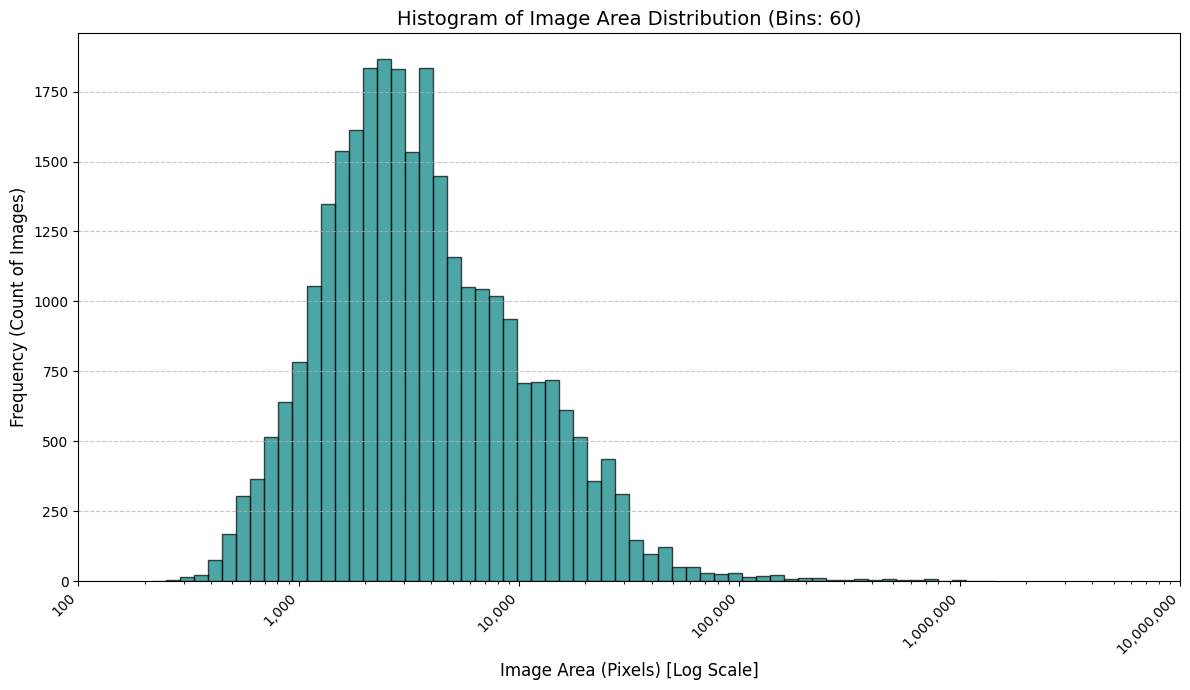

In [8]:
plot_hist_of_area(area_kept)

Plotting histogram of image area with 60 bins...
Histogram saved as 'image_area_histogram_log.png'


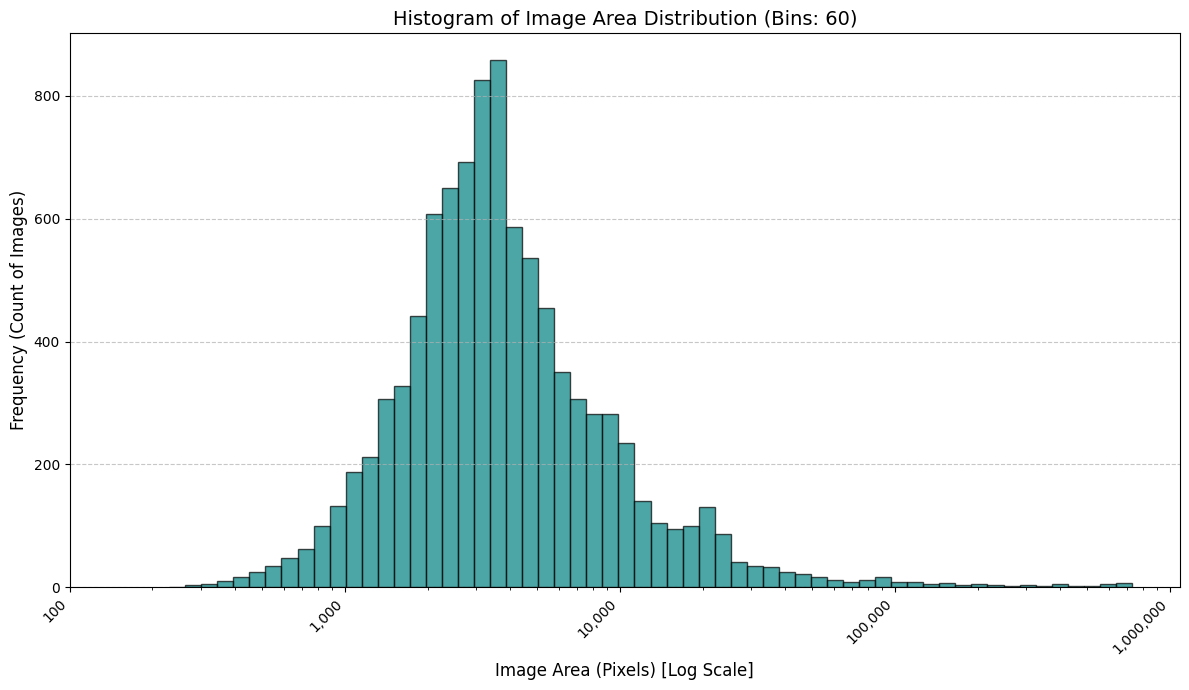

In [9]:
plot_hist_of_area(area_deleted)

plot all three overlapping 

✅ Overlapping histogram saved as 'overlapping_area_histograms_log.png'


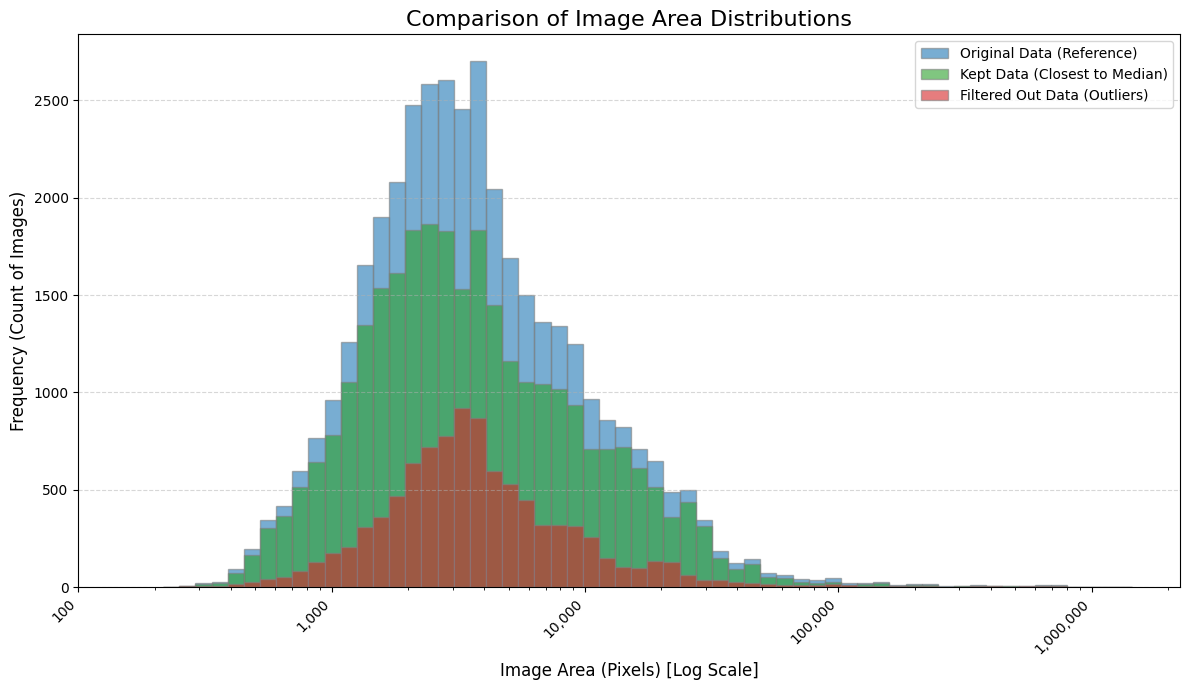

In [10]:


# --- 1. DATA TRANSFORMATION FUNCTION (Simplified for Area) ---

def transform_area_dict_to_numerical_list(area_counts_dict):
    """
    Converts an area count dictionary (int/float: int) into an unrolled list of 
    numerical areas (int/float).
    
    Returns: list_of_areas
    """
    numerical_areas = []
    
    for area, count in area_counts_dict.items():
        # Keys are already the numerical values (areas).
        # Extend the list by the numerical area 'count' times
        numerical_areas.extend([area] * count)
        
    return numerical_areas





dict_original = ab
dict_kept = area_kept
dict_filtered_out = area_deleted

# Define the data lists and labels
data_to_plot = [dict_original, dict_kept, dict_filtered_out]
labels = ["Original Data (Reference)", "Kept Data (Closest to Median)", "Filtered Out Data (Outliers)"]
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red for contrast
N_BINS = 60 # Number of bins for the histogram
USE_LOG_SCALE = True # Recommended for area distributions
# ------------------------------------------------------------------


# --- 3. DATA PREPARATION ---

all_numerical_data = []

for area_dict in data_to_plot:
    # 3a. Convert dictionary to numerical list
    numerical_list = transform_area_dict_to_numerical_list(area_dict)
    all_numerical_data.append(numerical_list)


# Combine all data to determine the global min/max for uniform binning
# Filter out empty lists before concatenation
non_empty_data = [np.array(d) for d in all_numerical_data if d]
if not non_empty_data:
    print("Error: No valid numerical data generated from the dictionaries.")
    exit()

combined_data = np.concatenate(non_empty_data)


# Calculate uniform bin edges based on the combined data range
if USE_LOG_SCALE:
    # Use log space for binning
    min_area = np.min(combined_data[combined_data > 0]) # Ensure > 0 for log
    max_area = np.max(combined_data)
    bin_edges = np.logspace(np.log10(min_area), np.log10(max_area), N_BINS + 1)
else:
    # Use linear space for binning
    min_val = np.min(combined_data)
    max_val = np.max(combined_data)
    bin_edges = np.linspace(min_val, max_val, N_BINS + 1)


# --- 4. PLOTTING ---

plt.figure(figsize=(12, 7))

# Plot the three histograms
for i, data_list in enumerate(all_numerical_data):
    plt.hist(
        data_list,
        bins=bin_edges,             # Critical: Use the same bins for all
        label=labels[i],
        color=colors[i],
        alpha=0.6,                  # Sets the transparency for overlap
        edgecolor='gray'            # Adds visible separation between bars
    )

# 5. X-AXIS FORMATTING (Numerical Area)

if USE_LOG_SCALE:
    plt.xscale('log')
    x_label = "Image Area (Pixels) [Log Scale]"
    
    # Improve tick visibility by labeling powers of 10
    ax = plt.gca()
    start_power = int(np.floor(np.log10(np.min(combined_data[combined_data > 0]))))
    end_power = int(np.ceil(np.log10(np.max(combined_data))))
    
    log_ticks = [10**i for i in range(start_power, end_power + 1) if 10**i <= max_area]
    log_labels = [f'{t:,}' for t in log_ticks]
    
    # Only use custom log labels if they don't clutter the axis too much
    if len(log_ticks) <= 12:
         ax.set_xticks(log_ticks)
         ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=10)
    else:
         plt.xticks(rotation=45, ha='right', fontsize=10)
         
else:
    x_label = "Image Area (Pixels)"
    plt.xticks(rotation=45, ha='right', fontsize=10)


# Final formatting
plt.xlabel(x_label, fontsize=12)
plt.ylabel("Frequency (Count of Images)", fontsize=12)
plt.title("Comparison of Image Area Distributions", fontsize=16)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. Save the plot
output_filename = "overlapping_area_histograms_log.png" if USE_LOG_SCALE else "overlapping_area_histograms_linear.png"
plt.savefig(output_filename)
print(f"✅ Overlapping histogram saved as '{output_filename}'")